# Deep Learning sur N-Grammes (CNN 1D)

Ce notebook implémente un **CNN 1D** en PyTorch pour classifier les avis Yelp à partir de features N-grammes.

**Grille** : *Deep-Ngram* → 1 pt | *Arch Deep: plusieurs* → 4 pts

### Architecture CNN 1D
```
Input → Conv1d(kernels 3,4,5) → MaxPool → Dense → Output
```

### Deux tâches de classification
1. **Polarité** (3 classes) : négatif (1-2★), neutre (3★), positif (4-5★)
2. **Score** (5 classes) : prédiction directe des étoiles (1-5)

## 0. Imports et Configuration

In [1]:
import sys
sys.path.insert(0, '../..')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

from src.data_utils import load_parquet
from src.visualization import setup_plot_style, save_figure

import warnings
warnings.filterwarnings('ignore')

setup_plot_style()

# Chemins
MODELS_DIR = '../../models/'
os.makedirs(MODELS_DIR, exist_ok=True)

# Device
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device : {DEVICE}')
print(f'PyTorch version : {torch.__version__}')

Device : mps
PyTorch version : 2.10.0


## 1. Chargement et Préparation des Données

In [2]:
df = load_parquet('reviews_clean.parquet', base_path='../../data/cleaned', columns=['text', 'stars'])
df = df.dropna(subset=['text', 'stars'])
print(f'Dimensions du dataset : {df.shape}')
print(f"Distribution des étoiles :\n{df['stars'].value_counts(normalize=True).sort_index()}")

Loaded 999,985 rows from reviews_clean.parquet
Dimensions du dataset : (999985, 2)
Distribution des étoiles :
stars
1    0.153056
2    0.077629
3    0.098714
4    0.207953
5    0.462647
Name: proportion, dtype: float64


In [3]:
# Échantillonnage — 10K comme les notebooks ML classique
SAMPLE_SIZE = 10_000
df_sample = df.sample(n=SAMPLE_SIZE, random_state=42)

X = df_sample['text']
# Polarité : 3 classes (0=négatif, 1=neutre, 2=positif)
df_sample['polarity'] = df_sample['stars'].apply(lambda x: 0 if x <= 2 else (1 if x == 3 else 2))
y_polarity = df_sample['polarity'].values
# Score : 1-5 → 0-4 pour PyTorch
y_score = (df_sample['stars'].astype(int) - 1).values

# Split 80/10/10 — stratifié sur la polarité
X_train, X_temp, y_pol_train, y_pol_temp, y_sc_train, y_sc_temp = train_test_split(
    X, y_polarity, y_score, test_size=0.20, random_state=42, stratify=y_polarity
)
X_val, X_test, y_pol_val, y_pol_test, y_sc_val, y_sc_test = train_test_split(
    X_temp, y_pol_temp, y_sc_temp, test_size=0.50, random_state=42, stratify=y_pol_temp
)

print(f'Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}')
print(f'\nDistribution Polarité : {np.bincount(y_pol_train)}')
print(f'Distribution Score    : {np.bincount(y_sc_train)}')

Train : 8000 | Val : 1000 | Test : 1000

Distribution Polarité : [1843  796 5361]
Distribution Score    : [1257  586  796 1624 3737]


## 2. Vectorisation N-Grammes

Même configuration que `02-ml-ngram.ipynb` : `CountVectorizer` avec `ngram_range=(1,2)` et `max_features=10000`.

In [4]:
VOCAB_SIZE = 10_000

vectorizer = CountVectorizer(
    max_features=VOCAB_SIZE,
    min_df=5,
    max_df=0.7,
    ngram_range=(1, 2)
)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec   = vectorizer.transform(X_val)
X_test_vec  = vectorizer.transform(X_test)

print(f'Matrice train : {X_train_vec.shape}')

Matrice train : (8000, 10000)


## 3. Dataset PyTorch

On convertit les matrices sparse en tenseurs denses. Pour le CNN 1D, on traite chaque document comme une séquence de longueur 1 avec `VOCAB_SIZE` features.

In [5]:
class NgramDataset(Dataset):
    """Dataset PyTorch pour les features N-grammes (sparse matrix → dense tensor)."""
    
    def __init__(self, X_sparse, y_labels):
        self.X = torch.tensor(X_sparse.toarray(), dtype=torch.float32)
        self.y = torch.tensor(y_labels, dtype=torch.long)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        # Shape: (VOCAB_SIZE,) → unsqueeze → (1, VOCAB_SIZE) pour Conv1d
        return self.X[idx].unsqueeze(0), self.y[idx]


BATCH_SIZE = 64

def make_loaders(y_train, y_val, y_test):
    """Crée les DataLoaders pour un jeu de labels donné."""
    train_ds = NgramDataset(X_train_vec, y_train)
    val_ds   = NgramDataset(X_val_vec,   y_val)
    test_ds  = NgramDataset(X_test_vec,  y_test)
    return (
        DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True),
        DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False),
        DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False),
    )

## 4. Architecture CNN 1D

Architecture : `Conv1d` parallèle avec kernels de taille **3**, **4** et **5** (à la Kim 2014), suivie d'un `MaxPool`, puis d'un classifieur dense.

```
Input : (batch, 1, VOCAB_SIZE)
  ↓
Conv1d(kernel=3) + ReLU + MaxPool  →  (batch, 128)
Conv1d(kernel=4) + ReLU + MaxPool  →  (batch, 128)
Conv1d(kernel=5) + ReLU + MaxPool  →  (batch, 128)
  ↓  concat
Dense(384 → 128) + ReLU + Dropout
Dense(128 → 5)
```

In [6]:
class TextCNN1D(nn.Module):
    """CNN 1D pour la classification de texte sur features N-grammes."""
    
    def __init__(self, vocab_size: int, num_classes: int = 5,
                 num_filters: int = 128, kernel_sizes=(3, 4, 5),
                 dropout: float = 0.5):
        super().__init__()
        
        # Convolutions parallèles avec kernels de tailles différentes
        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=1,
                out_channels=num_filters,
                kernel_size=k
            )
            for k in kernel_sizes
        ])
        
        self.dropout = nn.Dropout(dropout)
        
        # Classifieur dense
        fc_in = num_filters * len(kernel_sizes)
        self.fc1 = nn.Linear(fc_in, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # x : (batch, 1, vocab_size)
        pooled_outputs = []
        for conv in self.convs:
            h = self.relu(conv(x))          # (batch, num_filters, L)
            h = h.max(dim=2).values         # Global max-pool → (batch, num_filters)
            pooled_outputs.append(h)
        
        out = torch.cat(pooled_outputs, dim=1)  # (batch, num_filters * n_kernels)
        out = self.dropout(out)
        out = self.relu(self.fc1(out))
        out = self.dropout(out)
        out = self.fc2(out)
        return out


# Vérification de l'architecture
model_test = TextCNN1D(vocab_size=VOCAB_SIZE, num_classes=5)
print(model_test)
total_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f'\nParamètres entraînables : {total_params:,}')
del model_test

TextCNN1D(
  (convs): ModuleList(
    (0): Conv1d(1, 128, kernel_size=(3,), stride=(1,))
    (1): Conv1d(1, 128, kernel_size=(4,), stride=(1,))
    (2): Conv1d(1, 128, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=5, bias=True)
  (relu): ReLU()
)

Paramètres entraînables : 51,845


## 5. Fonctions d'entraînement et d'évaluation

In [7]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct += (logits.argmax(1) == y_batch).sum().item()
        total   += len(y_batch)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        total_loss += loss.item() * len(y_batch)
        correct += (logits.argmax(1) == y_batch).sum().item()
        total   += len(y_batch)
    return total_loss / total, correct / total


def train_cnn(model, train_loader, val_loader, epochs=15, lr=1e-3, patience=3):
    """Entraîne le CNN avec early stopping. Retourne le modèle et l'historique."""
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0
    
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
        vl_loss, vl_acc = eval_epoch(model, val_loader, criterion, DEVICE)
        
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        
        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        
        if (epoch) % 5 == 0 or patience_counter >= patience:
            print(f'Epoch {epoch:2d}/{epochs} | '
                  f'Train loss: {tr_loss:.4f} acc: {tr_acc:.4f} | '
                  f'Val loss: {vl_loss:.4f} acc: {vl_acc:.4f}')
        
        if patience_counter >= patience:
            print(f"Early stopping à l'epoch {epoch}.")
            break
    
    model.load_state_dict(best_state)
    return model, history


def evaluate_and_report(model, test_loader, target_names, title):
    """Évalue le modèle et affiche les métriques + confusion matrix."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(DEVICE)
            logits = model(X_batch)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(y_batch.numpy())
    
    preds  = np.array(all_preds)
    labels = np.array(all_labels)
    
    acc  = accuracy_score(labels, preds)
    f1   = f1_score(labels, preds, average='macro', zero_division=0)
    prec = precision_score(labels, preds, average='macro', zero_division=0)
    rec  = recall_score(labels, preds, average='macro', zero_division=0)
    
    print(f'\n=== {title} ===')
    print(f'Accuracy  : {acc:.4f}')
    print(f'F1 Macro  : {f1:.4f}')
    print(f'Precision : {prec:.4f}')
    print(f'Recall    : {rec:.4f}')
    print(classification_report(labels, preds, target_names=target_names, zero_division=0))
    
    # Matrice de confusion
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Matrice de Confusion — {title}')
    plt.ylabel('Vrai')
    plt.xlabel('Prédit')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    return acc, f1


def plot_training_curves(history, title, filename=None):
    """Affiche les courbes de loss et accuracy."""
    epochs_ran = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(epochs_ran, history['train_loss'], label='Train', marker='o')
    axes[0].plot(epochs_ran, history['val_loss'],   label='Val',   marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('CrossEntropy Loss')
    axes[0].set_title(f'{title} — Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    axes[1].plot(epochs_ran, history['train_acc'], label='Train', marker='o', color='darkorange')
    axes[1].plot(epochs_ran, history['val_acc'],   label='Val',   marker='s', color='steelblue')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    if filename:
        save_figure(filename, output_dir='../../outputs/figures')
    plt.show()

In [8]:
print("=" * 60)
print("TÂCHE 1 : POLARITÉ (négatif / neutre / positif)")
print("=" * 60)

train_pol, val_pol, test_pol = make_loaders(y_pol_train, y_pol_val, y_pol_test)

model_pol = TextCNN1D(vocab_size=VOCAB_SIZE, num_classes=3).to(DEVICE)
model_pol, history_pol = train_cnn(model_pol, train_pol, val_pol)

TÂCHE 1 : POLARITÉ (négatif / neutre / positif)


Epoch  5/15 | Train loss: 0.8390 acc: 0.6686 | Val loss: 0.8224 acc: 0.6700


Epoch 10/15 | Train loss: 0.8260 acc: 0.6703 | Val loss: 0.8177 acc: 0.6700


Epoch 13/15 | Train loss: 0.8253 acc: 0.6699 | Val loss: 0.8199 acc: 0.6690
Early stopping à l'epoch 13.


### Courbes et évaluation — Polarité

Figure saved to: ../../outputs/figures/cnn_ngram_polarite_curves.png


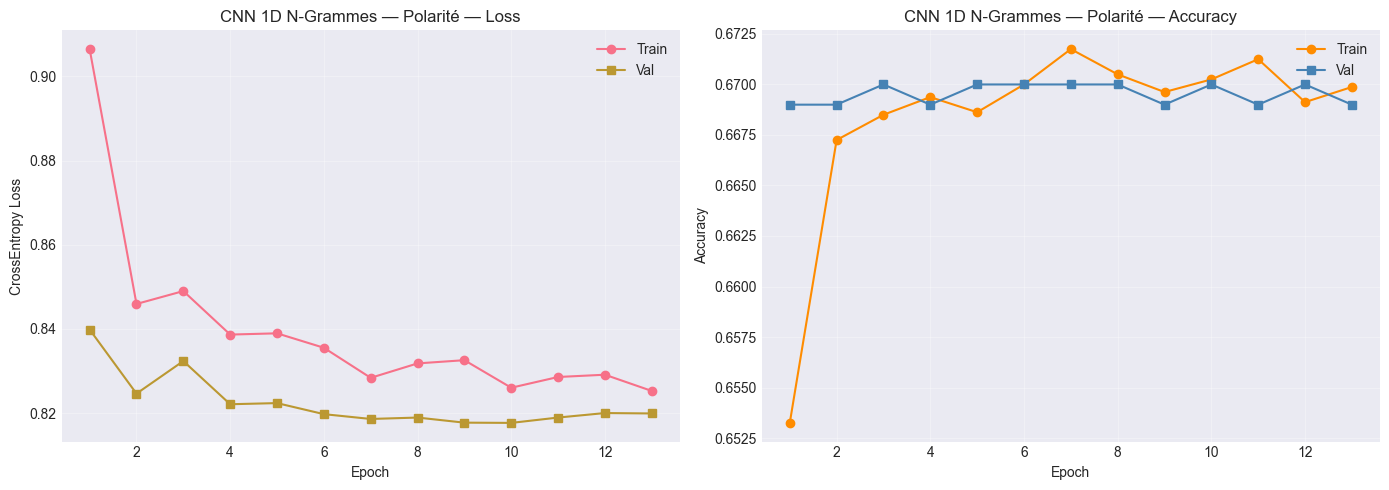


=== CNN 1D N-Grammes — Polarité ===
Accuracy  : 0.6700
F1 Macro  : 0.2731
Precision : 0.3571
Recall    : 0.3352
              precision    recall  f1-score   support

     Négatif       0.40      0.01      0.02       231
      Neutre       0.00      0.00      0.00        99
     Positif       0.67      1.00      0.80       670

    accuracy                           0.67      1000
   macro avg       0.36      0.34      0.27      1000
weighted avg       0.54      0.67      0.54      1000



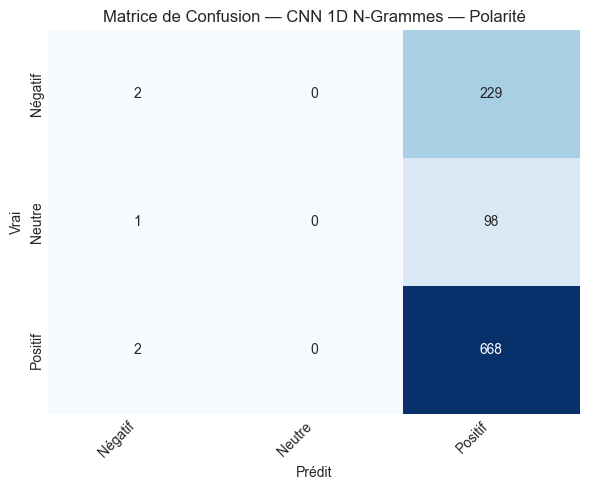

In [9]:
plot_training_curves(history_pol, 'CNN 1D N-Grammes — Polarité', 'cnn_ngram_polarite_curves.png')
acc_pol, f1_pol = evaluate_and_report(
    model_pol, test_pol, ['Négatif', 'Neutre', 'Positif'], 'CNN 1D N-Grammes — Polarité'
)

---
## 7. Tâche 2 : Prédiction du Score (1-5 étoiles)

In [10]:
print("=" * 60)
print("TÂCHE 2 : SCORE (1 à 5 étoiles)")
print("=" * 60)

train_sc, val_sc, test_sc = make_loaders(y_sc_train, y_sc_val, y_sc_test)

model_score = TextCNN1D(vocab_size=VOCAB_SIZE, num_classes=5).to(DEVICE)
model_score, history_score = train_cnn(model_score, train_sc, val_sc)

TÂCHE 2 : SCORE (1 à 5 étoiles)


Epoch  5/15 | Train loss: 1.3885 acc: 0.4671 | Val loss: 1.3899 acc: 0.4570


Epoch 10/15 | Train loss: 1.3804 acc: 0.4682 | Val loss: 1.3847 acc: 0.4570


Epoch 13/15 | Train loss: 1.3781 acc: 0.4686 | Val loss: 1.3855 acc: 0.4560
Early stopping à l'epoch 13.


Figure saved to: ../../outputs/figures/cnn_ngram_score_curves.png


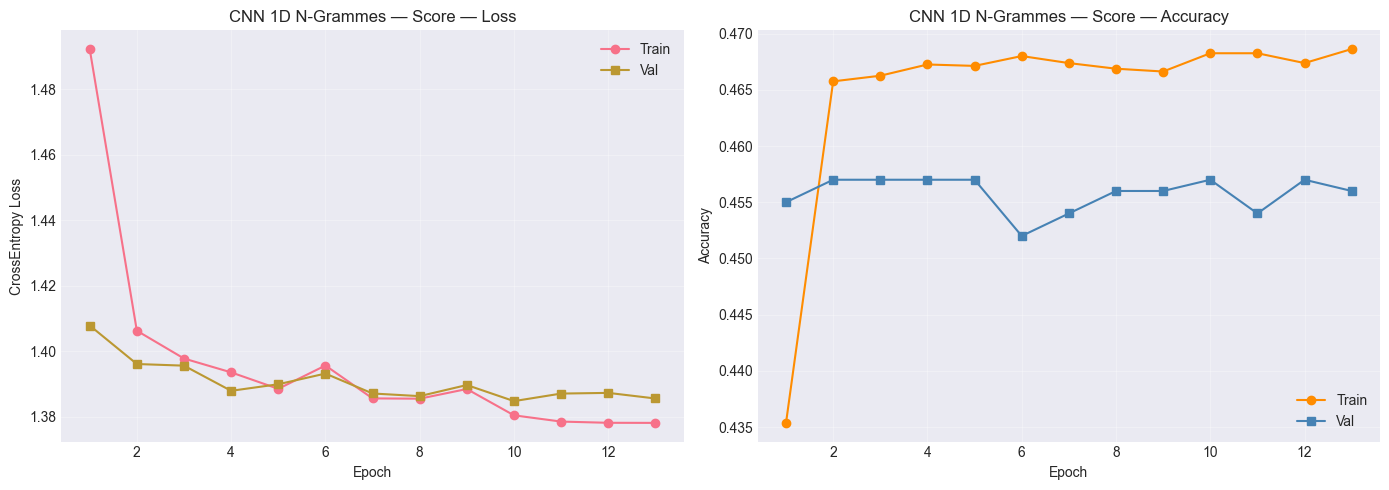


=== CNN 1D N-Grammes — Score ===
Accuracy  : 0.4500
F1 Macro  : 0.1241
Precision : 0.0900
Recall    : 0.2000
              precision    recall  f1-score   support

          1★       0.00      0.00      0.00       155
          2★       0.00      0.00      0.00        76
          3★       0.00      0.00      0.00        99
          4★       0.00      0.00      0.00       220
          5★       0.45      1.00      0.62       450

    accuracy                           0.45      1000
   macro avg       0.09      0.20      0.12      1000
weighted avg       0.20      0.45      0.28      1000



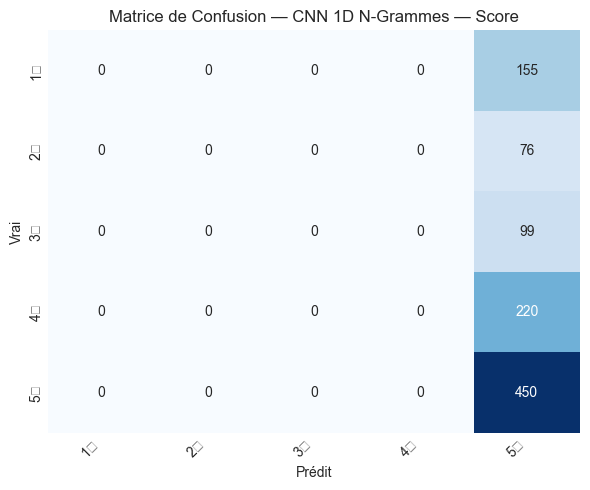

In [11]:
plot_training_curves(history_score, 'CNN 1D N-Grammes — Score', 'cnn_ngram_score_curves.png')
acc_sc, f1_sc = evaluate_and_report(
    model_score, test_sc, [f'{i+1}★' for i in range(5)], 'CNN 1D N-Grammes — Score'
)

---
## 8. Sauvegarde des modèles

import joblib

# Sauvegarder les modèles PyTorch
torch.save(model_pol.state_dict(), os.path.join(MODELS_DIR, 'cnn1d_ngram_polarity.pt'))
torch.save(model_score.state_dict(), os.path.join(MODELS_DIR, 'cnn1d_ngram_score.pt'))

# Sauvegarder le vectorizer
joblib.dump(vectorizer, os.path.join(MODELS_DIR, 'count_vectorizer_deep.pkl'))

print(f'Modèle Polarité : {MODELS_DIR}/cnn1d_ngram_polarity.pt')
print(f'Modèle Score    : {MODELS_DIR}/cnn1d_ngram_score.pt')
print(f'Vectorizer      : {MODELS_DIR}/count_vectorizer_deep.pkl')

In [12]:
import joblib

# Sauvegarder les modèles PyTorch
torch.save(model_pol.state_dict(), os.path.join(MODELS_DIR, 'cnn1d_ngram_polarity.pt'))
torch.save(model_score.state_dict(), os.path.join(MODELS_DIR, 'cnn1d_ngram_score.pt'))

# Sauvegarder le vectorizer
joblib.dump(vectorizer, os.path.join(MODELS_DIR, 'count_vectorizer_deep.pkl'))

print(f'Modèle Polarité : {MODELS_DIR}/cnn1d_ngram_polarity.pt')
print(f'Modèle Score    : {MODELS_DIR}/cnn1d_ngram_score.pt')
print(f'Vectorizer      : {MODELS_DIR}/count_vectorizer_deep.pkl')

Modèle Polarité : ../../models//cnn1d_ngram_polarity.pt
Modèle Score    : ../../models//cnn1d_ngram_score.pt
Vectorizer      : ../../models//count_vectorizer_deep.pkl


In [13]:
comparison = pd.DataFrame({
    'Tâche': ['Polarité (3 classes)', 'Score (1-5)'],
    'Accuracy': [acc_pol, acc_sc],
    'F1 Macro': [f1_pol, f1_sc],
})
print("=== RÉSUMÉ CNN 1D N-GRAMMES ===")
display(comparison)

print(f"\nArchitecture : CNN 1D — Conv(k=3,4,5) + MaxPool + Dense")
print(f"Features     : CountVectorizer (ngram_range=(1,2), max_features={VOCAB_SIZE})")
print(f"Échantillon  : {SAMPLE_SIZE} avis")

=== RÉSUMÉ CNN 1D N-GRAMMES ===


,Tâche,Accuracy,F1 Macro
0,Polarité (3 classes),0.67,0.273117
1,Score (1-5),0.45,0.124138



Architecture : CNN 1D — Conv(k=3,4,5) + MaxPool + Dense
Features     : CountVectorizer (ngram_range=(1,2), max_features=10000)
Échantillon  : 10000 avis
